<a href="https://colab.research.google.com/github/Keerti2409/Machine-Learning/blob/main/MLproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.impute import SimpleImputer#to fill the NaN values


In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [73]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score

In [74]:
df=pd.read_csv("/content/kidney_disease.csv")
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [75]:
print(df["classification"].unique())

['ckd' 'ckd\t' 'notckd']


In [76]:
print(df["classification"].value_counts())

classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


In [77]:
df.shape#400 rows ,26 columns



(400, 26)

In [78]:
print(df.info())
print(df.describe())
print(df.isnull().sum())
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [79]:
print(df["classification"].value_counts())

classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64


In [80]:
numeric_columns = [
    "age", "bp", "sg", "al", "su",
    "bgr", "bu", "sc", "sod", "pot",
    "hemo"
]

categorical_columns = [
    "rbc", "pc", "pcc", "ba",
    "pcv", "wc", "rc",
    "htn", "dm", "cad",
    "appet", "pe", "ane"
]

In [81]:
for column in numeric_columns:
    df[column] = df[column].fillna(
        df[column].median()
    )

In [83]:
for column in categorical_columns:
    df[column] = df[column].fillna(
        df[column].mode()[0]
    )

In [84]:
print(df.isnull().sum())

id                0
age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64


In [20]:
encoder = LabelEncoder()

In [21]:
for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

In [23]:
df["classification"] = encoder.fit_transform(
    df["classification"]
)
print(df.head())

   id   age    bp     sg   al   su  rbc  pc  pcc  ba  ...  pcv  wc  rc  htn  \
0   0  48.0  80.0  1.020  1.0  0.0    1   1    0   0  ...   32  72  34    1   
1   1   7.0  50.0  1.020  4.0  0.0    1   1    0   0  ...   26  56  34    0   
2   2  62.0  80.0  1.010  2.0  3.0    1   1    0   0  ...   19  70  34    0   
3   3  48.0  70.0  1.005  4.0  0.0    1   0    1   0  ...   20  62  19    1   
4   4  51.0  80.0  1.010  2.0  0.0    1   1    0   0  ...   23  68  27    0   

   dm  cad  appet  pe  ane  classification  
0   4    1      0   0    0               0  
1   3    1      0   0    0               0  
2   4    1      1   0    1               0  
3   3    1      1   1    1               0  
4   3    1      0   0    0               0  

[5 rows x 26 columns]


In [61]:
print(df[df["classification"] == 1])

      id   age    bp    sg   al   su  rbc  pc  pcc  ba  ...  pcv  wc  rc  htn  \
37    37  72.0  80.0  1.02  0.0  0.0    1   1    0   0  ...   16  64   4    1   
230  230  65.0  60.0  1.01  2.0  0.0    1   0    1   0  ...   29  87  34    1   

     dm  cad  appet  pe  ane  classification  
37    4    1      1   0    1               1  
230   4    1      1   0    0               1  

[2 rows x 26 columns]


In [60]:
print(encoder.inverse_transform([0, 1, 2]))

[0 1 2]


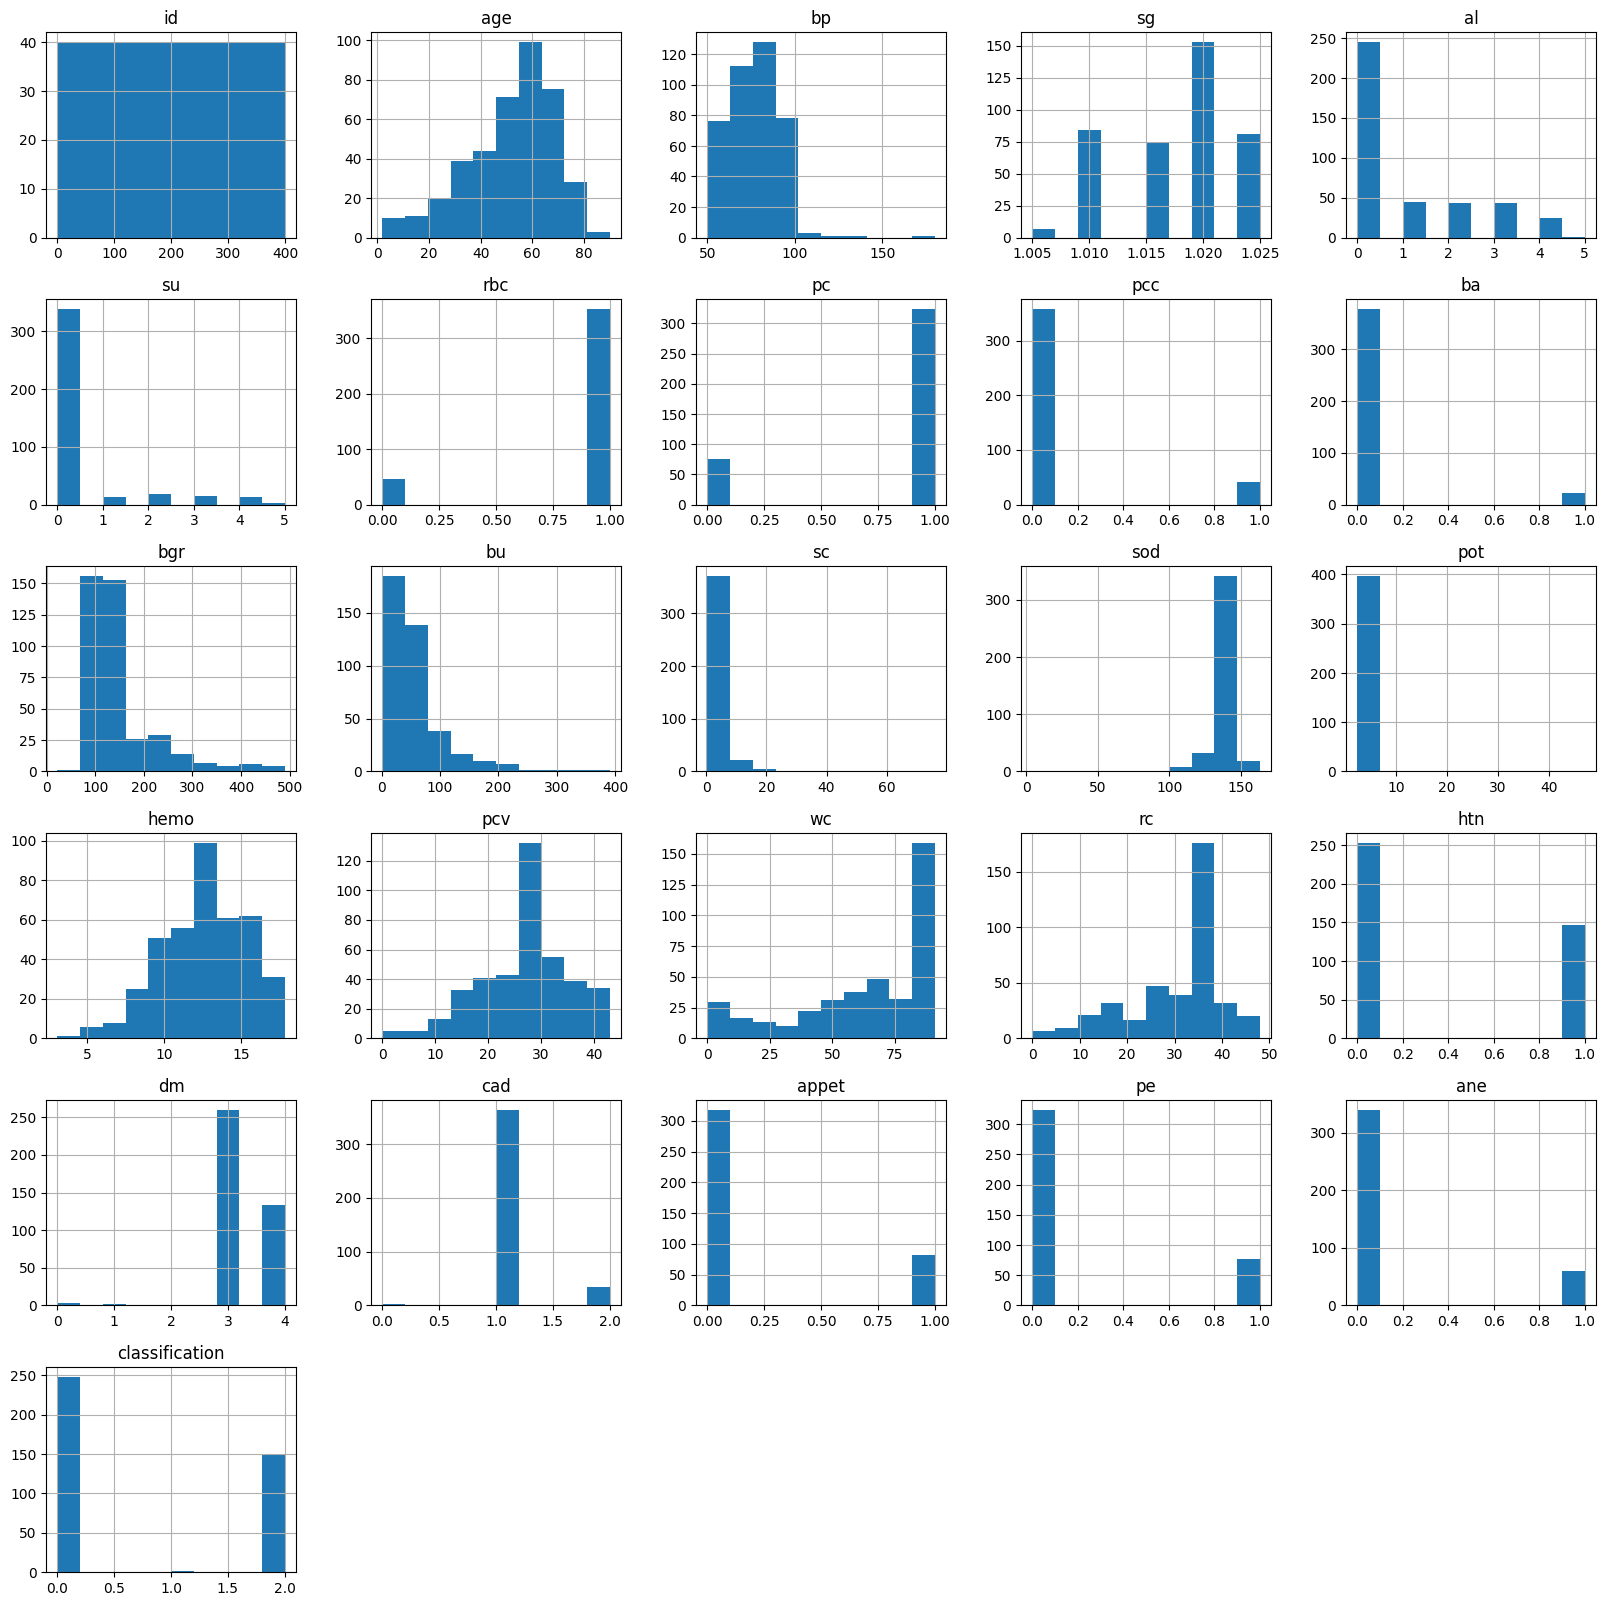

In [24]:
df.hist(figsize=(20,20))

plt.show()

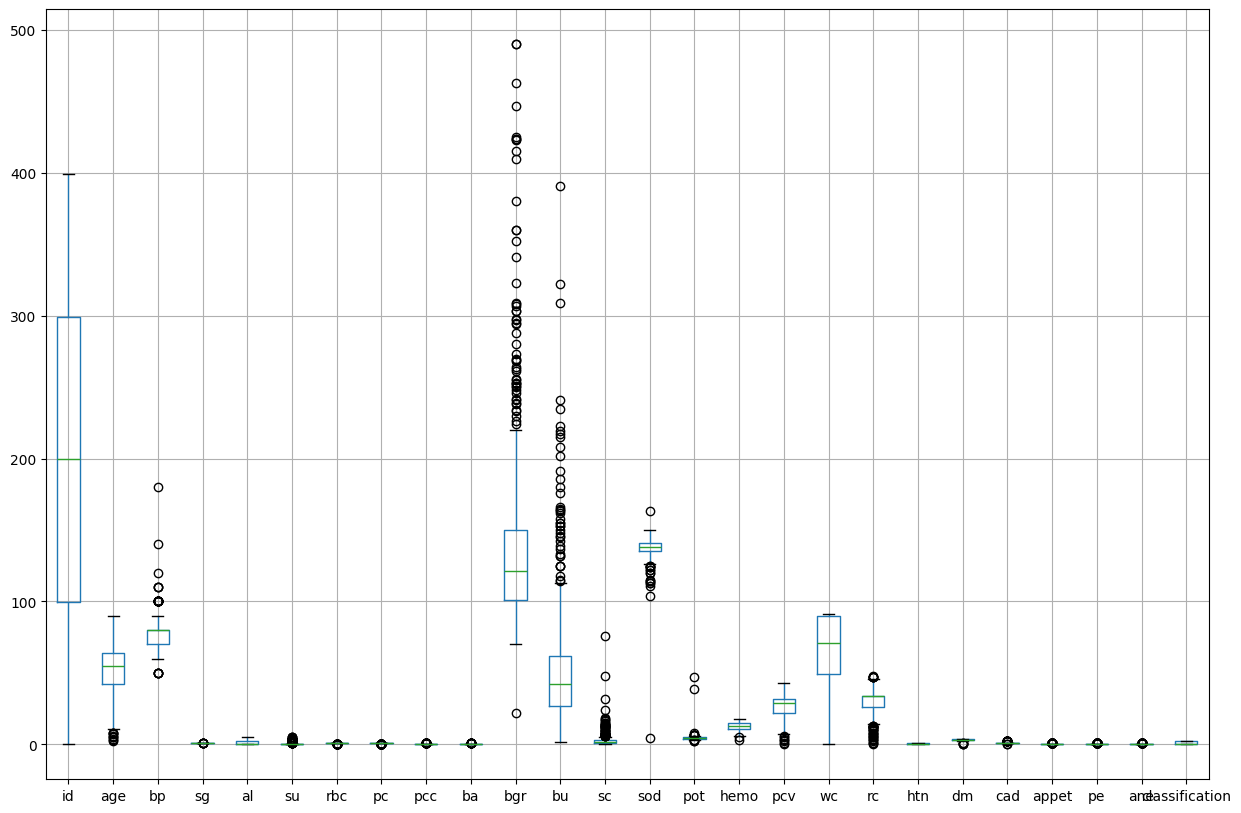

In [25]:
df.boxplot(figsize=(15,10))

plt.show()

In [27]:
Q1 = df["bu"].quantile(0.25)

Q3 = df["bu"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

print("Q1:", Q1)

print("Q3:", Q3)

print("IQR:", IQR)

print("Lower:", lower)

print("Upper:", upper)

Q1: 27.0
Q3: 61.75
IQR: 34.75
Lower: -25.125
Upper: 113.875


In [28]:
outliers = df[
    (df["bu"] < lower) |
    (df["bu"] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 41


In [29]:
df["bu"] = df["bu"].clip(
    lower=lower,
    upper=upper
)

In [30]:
Q1 = df["bu"].quantile(0.25)

Q3 = df["bu"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

outliers = df[
    (df["bu"] < lower) |
    (df["bu"] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 0


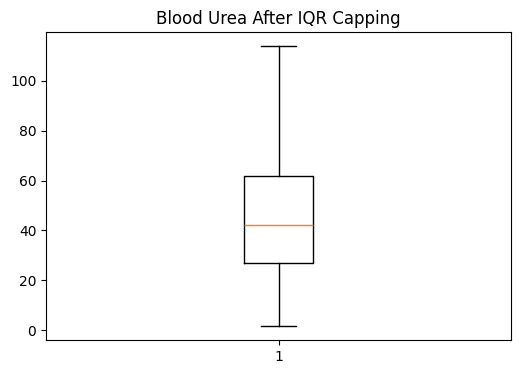

In [31]:
plt.figure(figsize=(6,4))

plt.boxplot(df["bu"])

plt.title("Blood Urea After IQR Capping")

plt.show()

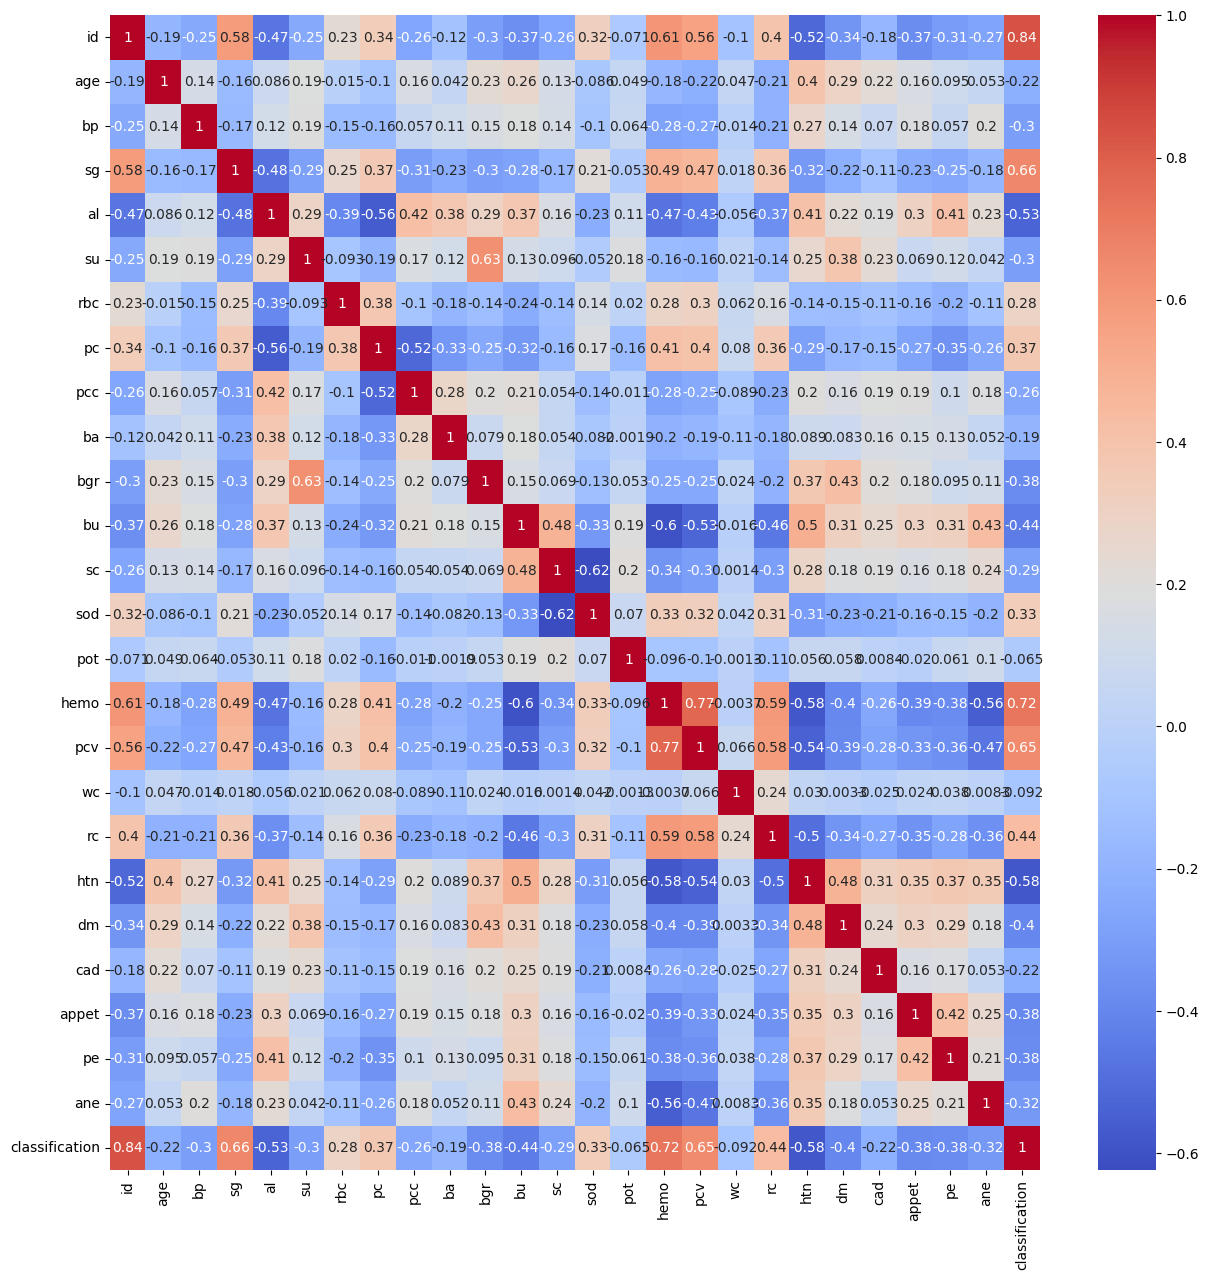

In [32]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(15,15))

sb.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [34]:
x = df.drop(
    ["id", "classification"],
    axis=1
)

y = df["classification"]

In [62]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)

In [37]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(x_train, y_train)

y_pred = log_model.predict(x_test)

In [39]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

Accuracy: 0.9875

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        50
           2       0.97      1.00      0.98        30

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80


Confusion Matrix:
[[49  1]
 [ 0 30]]


In [40]:
from sklearn.metrics import roc_auc_score

y_prob = log_model.predict_proba(x_test)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.534


In [41]:
from sklearn.neighbors import KNeighborsClassifier

In [42]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(x_train, y_train)

y_pred_knn = knn_model.predict(x_test)

In [43]:
from sklearn.metrics import accuracy_score

accuracy_knn = accuracy_score(
    y_test,
    y_pred_knn
)

print("KNN Accuracy:", accuracy_knn)

KNN Accuracy: 0.975


In [44]:
from sklearn.metrics import classification_report

print("KNN Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_knn
    )
)

KNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        50
           2       0.94      1.00      0.97        30

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80



In [46]:
from sklearn.metrics import confusion_matrix

cm_knn = confusion_matrix(
    y_test,
    y_pred_knn
)

print("KNN Confusion Matrix:")

print(cm_knn)

KNN Confusion Matrix:
[[48  2]
 [ 0 30]]


In [47]:
from sklearn.tree import DecisionTreeClassifier

In [48]:
decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(
    x_train,
    y_train
)

y_pred_dt = decision_tree_model.predict(
    x_test
)

In [49]:
accuracy_dt = accuracy_score(
    y_test,
    y_pred_dt
)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.925


In [68]:
decision_tree_model = DecisionTreeClassifier(random_state=42)

decision_tree_model.fit(x_train, y_train)

y_pred_dt = decision_tree_model.predict(x_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree Accuracy: 0.925
Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94        50
           1       0.00      0.00      0.00         0
           2       0.93      0.90      0.92        30

    accuracy                           0.93        80
   macro avg       0.62      0.61      0.62        80
weighted avg       0.94      0.93      0.93        80



In [51]:
cm_dt = confusion_matrix(
    y_test,
    y_pred_dt
)

print("Decision Tree Confusion Matrix:")

print(cm_dt)

Decision Tree Confusion Matrix:
[[47  1  2]
 [ 0  0  0]
 [ 3  0 27]]


In [52]:
from sklearn.ensemble import RandomForestClassifier

In [53]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(
    x_train,
    y_train
)

y_pred_rf = random_forest_model.predict(
    x_test
)

In [54]:
accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.9875


In [55]:
print("Random Forest Classification Report:")

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           2       1.00      0.97      0.98        30

    accuracy                           0.99        80
   macro avg       0.99      0.98      0.99        80
weighted avg       0.99      0.99      0.99        80



In [57]:
cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

print("Random Forest Confusion Matrix:")

print(cm_rf)

Random Forest Confusion Matrix:
[[50  0]
 [ 1 29]]


In [96]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

ann_model = Sequential()

ann_model.add(Input(shape=(x_train.shape[1],)))

ann_model.add(Dense(16, activation="relu"))

ann_model.add(Dense(8, activation="relu"))

ann_model.add(Dense(3, activation="softmax"))

ann_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 563 (2.20 KB)

 Trainable params: 563 (2.20 KB)

 Non-trainable params: 0 (0.00 B)

In [98]:
ann_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [99]:

history = ann_model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_split=0.2
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2773 - loss: 14.8248 - val_accuracy: 0.5000 - val_loss: 8.6360
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4492 - loss: 9.1487 - val_accuracy: 0.4688 - val_loss: 5.8936
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4023 - loss: 5.5898 - val_accuracy: 0.3281 - val_loss: 3.6771
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4258 - loss: 2.6400 - val_accuracy: 0.6094 - val_loss: 1.1066
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5781 - loss: 1.2139 - val_accuracy: 0.5000 - val_loss: 1.1351
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6055 - loss: 1.0037 - val_accuracy: 0.5781 - val_loss: 0.9004
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6172 - loss: 0.8726 - val_accuracy: 0.5156 - val_loss: 0.8827
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6328 - loss: 0.8297 - val_accuracy: 0.6250 - val_los

In [90]:
y_pred_prob = ann_model.predict(x_test)

y_pred_ann = np.argmax(y_pred_prob, axis=1)

print(y_pred_ann)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
[0 0 2 2 2 0 0 0 0 0 0 0 2 0 2 0 0 2 0 2 2 0 2 2 0 0 2 0 2 2 0 2 0 0 0 0 0
 0 2 2 0 0 2 0 0 0 0 2 0 0 0 0 2 0 0 0 2 0 0 2 0 2 2 0 0 2 0 0 0 0 2 0 0 0
 0 0 2 2 0 0]


In [100]:
from sklearn.metrics import accuracy_score

accuracy_ann = accuracy_score(y_test, y_pred_ann)

print("ANN Accuracy:", accuracy_ann)

ANN Accuracy: 0.9125


In [101]:
from sklearn.metrics import classification_report

print("ANN Classification Report:")
print(classification_report(y_test, y_pred_ann, zero_division=0))

ANN Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.96      0.93        50
           2       0.93      0.83      0.88        30

    accuracy                           0.91        80
   macro avg       0.92      0.90      0.90        80
weighted avg       0.91      0.91      0.91        80

